# 密度估计 benchmark：三种方法的统一比较

这个 notebook 从 `tm_vs_nis.ipynb` 中拆出，只负责比较三种连续密度估计方案：
- `transport map`：仿射下三角 transport-map 风格估计器；
- `kde`：`sklearn.neighbors.KernelDensity`；
- `knn`：基于 `NearestNeighbors` 的标准 kNN 密度估计。

目标是把这部分实验独立出来，便于单独复现、调参和记录结果，而不和互信息主线 notebook 混在一起。


In [1]:
from __future__ import annotations

import math
import os
import sys
from pathlib import Path
from typing import Any

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd().resolve() / "tmp" / "matplotlib").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

try:
    import matplotlib.pyplot as plt
except Exception:  # pragma: no cover - plotting fallback
    plt = None

import numpy as np
import pandas as pd

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "utils.py").exists():
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break

from utils import gaussian_mutual_information

try:
    from IPython.display import HTML, display
except Exception:  # pragma: no cover - notebook fallback
    HTML = None
    display = print

SEED = 7
RNG = np.random.default_rng(SEED)


In [2]:
def resolve_density_backend() -> str:
    """Return the density-estimation backend used in this notebook."""

    return "affine_triangular_transport_map"


def gaussian_logdet_bias_correction(dimension: int, sample_size: int) -> float:
    """Bias term of logdet(sample covariance) under a Gaussian/Wishart model."""

    from scipy.special import digamma

    if sample_size <= dimension:
        raise ValueError("sample_size must be larger than dimension for the Gaussian bias correction.")
    nu = sample_size - 1
    return float(
        sum(digamma((nu + 1 - index) / 2.0) for index in range(1, dimension + 1))
        + dimension * np.log(2.0)
        - dimension * np.log(nu)
    )


class AffineTransportMapDensityEstimator:
    """Affine lower-triangular transport map fitted from empirical moments."""

    def __init__(
        self,
        mean: np.ndarray,
        covariance: np.ndarray,
        *,
        backend: str,
        sample_size: int,
    ) -> None:
        self.mean = np.asarray(mean, dtype=float)
        self.covariance = np.asarray(covariance, dtype=float)
        self.backend = backend
        self.sample_size = int(sample_size)
        self.cholesky = np.linalg.cholesky(self.covariance)
        self.log_det_cholesky = float(np.log(np.diag(self.cholesky)).sum())
        self.dimension = int(self.mean.shape[0])

    def map_to_reference(self, samples: np.ndarray) -> np.ndarray:
        array = np.asarray(samples, dtype=float)
        centered = array - self.mean
        return np.linalg.solve(self.cholesky, centered.T).T

    def log_prob(self, samples: np.ndarray) -> np.ndarray:
        reference = self.map_to_reference(samples)
        quadratic = np.sum(reference**2, axis=1)
        return -0.5 * (self.dimension * np.log(2.0 * np.pi) + quadratic) - self.log_det_cholesky

    def marginal(self, indices: list[int] | tuple[int, ...]) -> 'AffineTransportMapDensityEstimator':
        subset = list(indices)
        return AffineTransportMapDensityEstimator(
            mean=self.mean[subset],
            covariance=self.covariance[np.ix_(subset, subset)],
            backend=self.backend,
            sample_size=self.sample_size,
        )


def fit_density(
    samples: np.ndarray,
    *,
    max_epochs: int = 200,
    hidden_features: int = 64,
    seed: int = 0,
) -> AffineTransportMapDensityEstimator:
    """Fit an affine triangular transport map from the empirical Gaussian moments."""

    del max_epochs, hidden_features, seed  # kept for a stable public API

    backend = resolve_density_backend()
    array = np.asarray(samples, dtype=float)
    if array.ndim != 2 or array.shape[0] < 2:
        raise ValueError("samples must be a 2D array with at least two rows.")

    mean = array.mean(axis=0)
    covariance = np.cov(array, rowvar=False, bias=False)
    covariance = np.atleast_2d(covariance)
    covariance += 1e-6 * np.eye(covariance.shape[0])
    return AffineTransportMapDensityEstimator(
        mean=mean,
        covariance=covariance,
        backend=backend,
        sample_size=array.shape[0],
    )


def estimate_mutual_information_transport_map(
    x: np.ndarray,
    y: np.ndarray,
    *,
    max_epochs: int = 200,
    hidden_features: int = 64,
    seed: int = 0,
) -> dict[str, Any]:
    """Estimate mutual information by fitting joint and marginal transport maps."""

    del seed

    x_array = np.asarray(x, dtype=float)
    y_array = np.asarray(y, dtype=float)
    if x_array.ndim != 2 or y_array.ndim != 2 or x_array.shape[0] != y_array.shape[0]:
        raise ValueError("x and y must be 2D arrays with matching sample counts.")

    sample_size = x_array.shape[0]
    joint = np.concatenate([x_array, y_array], axis=1)
    joint_model = fit_density(joint, max_epochs=max_epochs, hidden_features=hidden_features)
    x_model = joint_model.marginal(list(range(x_array.shape[1])))
    y_model = joint_model.marginal(list(range(x_array.shape[1], joint.shape[1])))

    log_pxy = joint_model.log_prob(joint)
    log_px = x_model.log_prob(x_array)
    log_py = y_model.log_prob(y_array)
    pointwise_mi_raw = log_pxy - log_px - log_py

    bias_correction = 0.5 * (
        gaussian_logdet_bias_correction(x_array.shape[1], sample_size)
        + gaussian_logdet_bias_correction(y_array.shape[1], sample_size)
        - gaussian_logdet_bias_correction(joint.shape[1], sample_size)
    )
    pointwise_mi = pointwise_mi_raw - bias_correction

    return {
        "backend": joint_model.backend,
        "mi_hat": float(pointwise_mi.mean()),
        "bias_correction": float(bias_correction),
        "log_pxy": log_pxy,
        "log_px": log_px,
        "log_py": log_py,
        "pointwise_mi": pointwise_mi,
    }


def estimate_mutual_information_knn(
    x: np.ndarray,
    y: np.ndarray,
    *,
    n_neighbors: int = 5,
) -> float:
    """A lightweight KSG-style baseline for continuous mutual information."""

    from scipy.special import digamma
    from sklearn.neighbors import NearestNeighbors

    x_array = np.asarray(x, dtype=float)
    y_array = np.asarray(y, dtype=float)
    if x_array.ndim != 2 or y_array.ndim != 2 or x_array.shape[0] != y_array.shape[0]:
        raise ValueError("x and y must be 2D arrays with matching sample counts.")

    n_samples = x_array.shape[0]
    if n_samples <= 1:
        raise ValueError("Need at least two samples for kNN mutual information.")
    k = min(max(1, int(n_neighbors)), n_samples - 1)

    joint = np.concatenate([x_array, y_array], axis=1)
    joint_nn = NearestNeighbors(metric="chebyshev", n_neighbors=k + 1)
    joint_nn.fit(joint)
    distances, _ = joint_nn.kneighbors(joint)
    radii = np.nextafter(distances[:, k], 0.0)

    x_nn = NearestNeighbors(metric="chebyshev")
    y_nn = NearestNeighbors(metric="chebyshev")
    x_nn.fit(x_array)
    y_nn.fit(y_array)

    nx = np.zeros(n_samples, dtype=int)
    ny = np.zeros(n_samples, dtype=int)
    for idx, radius in enumerate(radii):
        nx[idx] = len(x_nn.radius_neighbors(x_array[idx:idx + 1], radius=float(radius), return_distance=False)[0]) - 1
        ny[idx] = len(y_nn.radius_neighbors(y_array[idx:idx + 1], radius=float(radius), return_distance=False)[0]) - 1

    return float(digamma(k) + digamma(n_samples) - np.mean(digamma(nx + 1) + digamma(ny + 1)))


In [3]:
DENSITY_BENCHMARK_VERSION = "2026-03-31"

import json
import time
from scipy.special import gammaln, logsumexp
from scipy.stats import multivariate_normal
from sklearn.neighbors import KernelDensity, NearestNeighbors

DENSITY_FAMILY_SPECS = {
    'gaussian': {'title': 'Gaussian'},
    'gmm': {'title': 'Gaussian mixture'},
    'banana': {'title': 'Banana'},
}
DENSITY_METHOD_ORDER = ('transport_map', 'kde', 'knn')
DENSITY_METHOD_LABELS = {
    'transport_map': 'Transport map',
    'kde': 'KDE',
    'knn': 'kNN',
}
DENSITY_COLORS = {
    'transport_map': '#1f77b4',
    'kde': '#d97706',
    'knn': '#2a9d8f',
}
def resolve_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / 'utils.py').exists():
            return candidate
    return Path.cwd().resolve()


PROJECT_ROOT = resolve_project_root()
DENSITY_CACHE_DIR = PROJECT_ROOT / 'exp' / 'cache' / 'density_benchmark'
DENSITY_FIG_DIR = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
DENSITY_CACHE_DIR.mkdir(parents=True, exist_ok=True)
DENSITY_FIG_DIR.mkdir(parents=True, exist_ok=True)


def build_density_covariance(total_dim: int, *, decay: float = 0.65, latent_strength: float = 0.35) -> np.ndarray:
    if total_dim < 2:
        raise ValueError('total_dim must be at least 2.')
    indices = np.arange(total_dim)
    toeplitz = decay ** np.abs(indices[:, None] - indices[None, :])
    latent = np.stack(
        [
            np.linspace(0.4, 1.0, total_dim),
            np.cos(np.linspace(0.0, np.pi, total_dim)),
        ],
        axis=1,
    )
    covariance = 0.45 * toeplitz + latent_strength * (latent @ latent.T) + 0.55 * np.eye(total_dim)
    return 0.5 * (covariance + covariance.T)


def make_banana_transform(base_samples: np.ndarray, *, beta: float = 0.35) -> np.ndarray:
    warped = np.asarray(base_samples, dtype=float).copy()
    warped[:, 1] = warped[:, 1] + beta * (warped[:, 0] ** 2 - 1.0)
    return warped


def banana_inverse(samples: np.ndarray, *, beta: float = 0.35) -> np.ndarray:
    array = np.asarray(samples, dtype=float).copy()
    array[:, 1] = array[:, 1] - beta * (array[:, 0] ** 2 - 1.0)
    return array


def standard_gaussian_logpdf(samples: np.ndarray) -> np.ndarray:
    array = np.asarray(samples, dtype=float)
    dim = array.shape[1]
    return -0.5 * (dim * np.log(2.0 * np.pi) + np.sum(array ** 2, axis=1))


def build_density_family_dataset(
    family: str,
    *,
    total_dim: int,
    n_train: int,
    n_test: int,
    seed: int,
) -> dict[str, Any]:
    rng = np.random.default_rng(seed)
    if family == 'gaussian':
        covariance = build_density_covariance(total_dim)
        mean = np.zeros(total_dim, dtype=float)
        rv = multivariate_normal(mean=mean, cov=covariance, allow_singular=False)
        train = rng.multivariate_normal(mean, covariance, size=n_train)
        test = rng.multivariate_normal(mean, covariance, size=n_test)
        log_true = rv.logpdf(test)
        return {
            'family': family,
            'train': train,
            'test': test,
            'log_true_test': np.asarray(log_true, dtype=float),
        }

    if family == 'gmm':
        covariance_a = build_density_covariance(total_dim, decay=0.6, latent_strength=0.25)
        covariance_b = build_density_covariance(total_dim, decay=0.45, latent_strength=0.20) + 0.12 * np.eye(total_dim)
        mean_template = np.linspace(1.0, 0.2, total_dim)
        mean_a = 0.85 * mean_template
        mean_b = -0.85 * mean_template
        rv_a = multivariate_normal(mean=mean_a, cov=covariance_a, allow_singular=False)
        rv_b = multivariate_normal(mean=mean_b, cov=covariance_b, allow_singular=False)

        def sample(size: int) -> np.ndarray:
            component = rng.binomial(1, 0.5, size=size)
            samples = np.empty((size, total_dim), dtype=float)
            count_a = int(np.sum(component == 0))
            count_b = size - count_a
            if count_a > 0:
                samples[component == 0] = rng.multivariate_normal(mean_a, covariance_a, size=count_a)
            if count_b > 0:
                samples[component == 1] = rng.multivariate_normal(mean_b, covariance_b, size=count_b)
            return samples

        train = sample(n_train)
        test = sample(n_test)
        log_true = logsumexp(
            np.stack([
                np.log(0.5) + rv_a.logpdf(test),
                np.log(0.5) + rv_b.logpdf(test),
            ], axis=0),
            axis=0,
        )
        return {
            'family': family,
            'train': train,
            'test': test,
            'log_true_test': np.asarray(log_true, dtype=float),
        }

    if family == 'banana':
        if total_dim < 2:
            raise ValueError('banana family requires total_dim >= 2.')
        train_base = rng.normal(size=(n_train, total_dim))
        test_base = rng.normal(size=(n_test, total_dim))
        train = make_banana_transform(train_base)
        test = make_banana_transform(test_base)
        log_true = standard_gaussian_logpdf(banana_inverse(test))
        return {
            'family': family,
            'train': train,
            'test': test,
            'log_true_test': np.asarray(log_true, dtype=float),
        }

    raise KeyError(f'Unknown density family: {family}')


class KNNDensityEstimator:
    def __init__(self, samples: np.ndarray, *, n_neighbors: int = 10) -> None:
        array = np.asarray(samples, dtype=float)
        if array.ndim != 2 or array.shape[0] < 2:
            raise ValueError('samples must be a 2D array with at least two rows.')
        self.samples = array
        self.n_samples, self.dimension = array.shape
        self.n_neighbors = min(max(1, int(n_neighbors)), self.n_samples)
        self.model = NearestNeighbors(metric='euclidean', n_neighbors=self.n_neighbors)
        self.model.fit(array)
        self.log_unit_ball = 0.5 * self.dimension * np.log(np.pi) - gammaln(0.5 * self.dimension + 1.0)

    def log_prob(self, samples: np.ndarray) -> np.ndarray:
        query = np.asarray(samples, dtype=float)
        distances, _ = self.model.kneighbors(query, n_neighbors=self.n_neighbors)
        radii = np.maximum(distances[:, -1], 1e-12)
        return (
            np.log(self.n_neighbors)
            - np.log(self.n_samples)
            - self.log_unit_ball
            - self.dimension * np.log(radii)
        )


def estimate_scott_bandwidth(samples: np.ndarray) -> float:
    array = np.asarray(samples, dtype=float)
    n_samples, dim = array.shape
    scale = float(np.mean(np.std(array, axis=0, ddof=1)))
    scale = max(scale, 1e-3)
    return float(scale * n_samples ** (-1.0 / (dim + 4.0)))


def fit_transport_map_density_estimator(
    samples: np.ndarray,
    *,
    max_epochs: int = 200,
    hidden_features: int = 64,
    seed: int = 0,
) -> AffineTransportMapDensityEstimator:
    return fit_density(samples, max_epochs=max_epochs, hidden_features=hidden_features, seed=seed)



def fit_kde_density_estimator(samples: np.ndarray, *, bandwidth: float | None = None) -> KernelDensity:
    array = np.asarray(samples, dtype=float)
    bandwidth_value = estimate_scott_bandwidth(array) if bandwidth is None else float(bandwidth)
    bandwidth_value = max(bandwidth_value, 1e-3)
    estimator = KernelDensity(kernel='gaussian', bandwidth=bandwidth_value)
    estimator.fit(array)
    return estimator



def fit_knn_density_estimator(samples: np.ndarray, *, n_neighbors: int = 10) -> KNNDensityEstimator:
    return KNNDensityEstimator(samples, n_neighbors=n_neighbors)



def score_density_estimator(method: str, estimator: Any, samples: np.ndarray) -> np.ndarray:
    if method in ('transport_map', 'knn'):
        return np.asarray(estimator.log_prob(samples), dtype=float)
    if method == 'kde':
        return np.asarray(estimator.score_samples(np.asarray(samples, dtype=float)), dtype=float)
    raise KeyError(f'Unknown density method: {method}')



def evaluate_density_setting(
    *,
    family: str,
    total_dim: int,
    n_train: int,
    n_test: int = 2000,
    repeats: int = 4,
    seed: int = 0,
    knn_neighbors: int = 10,
) -> pd.DataFrame:
    rows: list[dict[str, float | int | str]] = []
    for repeat in range(repeats):
        dataset = build_density_family_dataset(
            family,
            total_dim=total_dim,
            n_train=n_train,
            n_test=n_test,
            seed=seed + 1000 * repeat,
        )
        train = dataset['train']
        test = dataset['test']
        log_true = dataset['log_true_test']

        for method in DENSITY_METHOD_ORDER:
            fit_start = time.perf_counter()
            if method == 'transport_map':
                estimator = fit_transport_map_density_estimator(train, seed=seed + repeat)
            elif method == 'kde':
                estimator = fit_kde_density_estimator(train)
            elif method == 'knn':
                estimator = fit_knn_density_estimator(train, n_neighbors=knn_neighbors)
            else:
                raise KeyError(method)
            fit_time = time.perf_counter() - fit_start

            score_start = time.perf_counter()
            log_hat = score_density_estimator(method, estimator, test)
            score_time = time.perf_counter() - score_start

            rows.append({
                'family': family,
                'family_title': DENSITY_FAMILY_SPECS[family]['title'],
                'method': method,
                'repeat': int(repeat),
                'total_dim': int(total_dim),
                'n_train': int(n_train),
                'n_test': int(n_test),
                'heldout_nll': float(-np.mean(log_hat)),
                'rmse_log_density': float(np.sqrt(np.mean((log_hat - log_true) ** 2))),
                'kl_p_phat': float(np.mean(log_true - log_hat)),
                'fit_time': float(fit_time),
                'score_time': float(score_time),
                'total_time': float(fit_time + score_time),
            })
    return pd.DataFrame(rows)



def summarize_density_results(results: pd.DataFrame, group_keys: list[str]) -> pd.DataFrame:
    summary = (
        results.groupby(group_keys + ['method'], as_index=False)
        .agg(
            heldout_nll_mean=('heldout_nll', 'mean'),
            heldout_nll_std=('heldout_nll', 'std'),
            rmse_log_density_mean=('rmse_log_density', 'mean'),
            rmse_log_density_std=('rmse_log_density', 'std'),
            kl_p_phat_mean=('kl_p_phat', 'mean'),
            kl_p_phat_std=('kl_p_phat', 'std'),
            fit_time_mean=('fit_time', 'mean'),
            score_time_mean=('score_time', 'mean'),
            total_time_mean=('total_time', 'mean'),
        )
        .sort_values(group_keys + ['method'])
        .reset_index(drop=True)
    )
    return summary.fillna(0.0)



def run_density_family_benchmark(
    *,
    families: tuple[str, ...] = ('gaussian', 'gmm', 'banana'),
    total_dim: int = 8,
    n_train: int = 2000,
    n_test: int = 2000,
    repeats: int = 4,
    seed: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    raw = pd.concat(
        [
            evaluate_density_setting(
                family=family,
                total_dim=total_dim,
                n_train=n_train,
                n_test=n_test,
                repeats=repeats,
                seed=seed + 100 * index,
            )
            for index, family in enumerate(families)
        ],
        ignore_index=True,
    )
    summary = summarize_density_results(raw, ['family', 'family_title'])
    return raw, summary



def run_density_dimension_benchmark(
    *,
    families: tuple[str, ...] = ('gaussian', 'gmm', 'banana'),
    total_dims: tuple[int, ...] = (2, 4, 8, 16),
    n_train: int = 2000,
    n_test: int = 2000,
    repeats: int = 3,
    seed: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    frames = []
    for family_index, family in enumerate(families):
        for dim_index, total_dim in enumerate(total_dims):
            frames.append(
                evaluate_density_setting(
                    family=family,
                    total_dim=total_dim,
                    n_train=n_train,
                    n_test=n_test,
                    repeats=repeats,
                    seed=seed + 1000 * family_index + 100 * dim_index,
                )
            )
    raw = pd.concat(frames, ignore_index=True)
    summary = summarize_density_results(raw, ['family', 'family_title', 'total_dim'])
    return raw, summary



def run_density_sample_size_benchmark(
    *,
    families: tuple[str, ...] = ('gaussian', 'gmm', 'banana'),
    total_dim: int = 8,
    sample_sizes: tuple[int, ...] = (200, 500, 1000, 2000),
    n_test: int = 2000,
    repeats: int = 3,
    seed: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    frames = []
    for family_index, family in enumerate(families):
        for sample_index, n_train in enumerate(sample_sizes):
            frames.append(
                evaluate_density_setting(
                    family=family,
                    total_dim=total_dim,
                    n_train=n_train,
                    n_test=n_test,
                    repeats=repeats,
                    seed=seed + 1000 * family_index + 100 * sample_index,
                )
            )
    raw = pd.concat(frames, ignore_index=True)
    summary = summarize_density_results(raw, ['family', 'family_title', 'n_train'])
    return raw, summary



def build_density_timing_summary(
    dimension_summary: pd.DataFrame,
    sample_size_summary: pd.DataFrame,
) -> pd.DataFrame:
    dim_df = (
        dimension_summary.groupby(['total_dim', 'method'], as_index=False)
        .agg(total_time_mean=('total_time_mean', 'mean'))
        .assign(scan='dimension')
        .rename(columns={'total_dim': 'x_value'})
    )
    sample_df = (
        sample_size_summary.groupby(['n_train', 'method'], as_index=False)
        .agg(total_time_mean=('total_time_mean', 'mean'))
        .assign(scan='sample_size')
        .rename(columns={'n_train': 'x_value'})
    )
    return pd.concat([dim_df, sample_df], ignore_index=True)



def plot_density_accuracy_summary(summary_df: pd.DataFrame) -> Any:
    import json
    if plt is None:
        display(summary_df)
        return summary_df

    fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.8), constrained_layout=True)
    metric_specs = [
        ('heldout_nll_mean', 'Held-out NLL'),
        ('rmse_log_density_mean', r'RMSE of $\log p$'),
        ('kl_p_phat_mean', r'$KL(p\|\hat p)$'),
    ]
    families = list(DENSITY_FAMILY_SPECS.keys())
    x = np.arange(len(families))
    width = 0.22

    handles = []
    labels = []
    for ax, (metric, ylabel) in zip(axes, metric_specs):
        for method_index, method in enumerate(DENSITY_METHOD_ORDER):
            frame = summary_df.loc[summary_df['method'] == method].set_index('family').reindex(families)
            offsets = x + (method_index - 1) * width
            bars = ax.bar(
                offsets,
                frame[metric],
                width=width,
                color=DENSITY_COLORS[method],
                alpha=0.88,
                label=DENSITY_METHOD_LABELS[method],
            )
            if not handles:
                pass
        ax.set_xticks(x)
        ax.set_xticklabels([DENSITY_FAMILY_SPECS[key]['title'] for key in families])
        ax.set_ylabel(ylabel)
        ax.grid(axis='y', alpha=0.25)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
    path = DENSITY_FIG_DIR / 'density_accuracy_summary.png'
    fig.savefig(path, dpi=220, bbox_inches='tight')
    return fig



def plot_density_robustness_scan(summary_df: pd.DataFrame, *, x_key: str, y_key: str, xlabel: str, output_name: str) -> Any:
    if plt is None:
        display(summary_df)
        return summary_df

    families = list(DENSITY_FAMILY_SPECS.keys())
    fig, axes = plt.subplots(1, len(families), figsize=(16.5, 4.8), constrained_layout=True, sharey=True)
    if len(families) == 1:
        axes = [axes]

    handles = None
    labels = None
    for ax, family in zip(axes, families):
        family_df = summary_df.loc[summary_df['family'] == family].sort_values(x_key)
        for method in DENSITY_METHOD_ORDER:
            method_df = family_df.loc[family_df['method'] == method]
            ax.plot(
                method_df[x_key],
                method_df[y_key],
                marker='o',
                linewidth=2.4,
                markersize=6.0,
                color=DENSITY_COLORS[method],
                label=DENSITY_METHOD_LABELS[method],
            )
        ax.set_title(DENSITY_FAMILY_SPECS[family]['title'])
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.25)
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()
    axes[0].set_ylabel('Held-out NLL')
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
    path = DENSITY_FIG_DIR / output_name
    fig.savefig(path, dpi=220, bbox_inches='tight')
    return fig



def plot_density_timing_summary(summary_df: pd.DataFrame) -> Any:
    import json
    if plt is None:
        display(summary_df)
        return summary_df

    fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8), constrained_layout=True)
    plot_specs = [
        ('dimension', 'x_value', 'Total dimension', 'Time vs dimension'),
        ('sample_size', 'x_value', 'Training samples', 'Time vs sample size'),
    ]
    handles = None
    labels = None
    for ax, (scan, x_key, xlabel, title) in zip(axes, plot_specs):
        scan_df = summary_df.loc[summary_df['scan'] == scan].sort_values(x_key)
        for method in DENSITY_METHOD_ORDER:
            method_df = scan_df.loc[scan_df['method'] == method]
            ax.plot(
                method_df[x_key],
                method_df['total_time_mean'],
                marker='o',
                linewidth=2.4,
                markersize=6.0,
                color=DENSITY_COLORS[method],
                label=DENSITY_METHOD_LABELS[method],
            )
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('seconds')
        ax.grid(alpha=0.25)
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
    path = DENSITY_FIG_DIR / 'density_timing_summary.png'
    fig.savefig(path, dpi=220, bbox_inches='tight')
    return fig



def density_pickle_path(path: Path) -> Path:
    return path.with_suffix('.pkl')


def can_use_parquet() -> bool:
    for module_name in ('pyarrow', 'fastparquet'):
        try:
            __import__(module_name)
            return True
        except ImportError:
            continue
    return False


def density_raw_cache_available(path: Path) -> bool:
    return density_pickle_path(path).exists() or (path.exists() and can_use_parquet())


def read_density_frame(path: Path) -> pd.DataFrame:
    pickle_path = density_pickle_path(path)
    if pickle_path.exists():
        return pd.read_pickle(pickle_path)
    if path.exists() and can_use_parquet():
        return pd.read_parquet(path)
    raise FileNotFoundError(
        f'No readable cache found for {path.name}. Expected {pickle_path.name}'
        ' or a usable parquet engine.'
    )


def write_density_frame(frame: pd.DataFrame, path: Path) -> list[str]:
    written = []
    pickle_path = density_pickle_path(path)
    frame.to_pickle(pickle_path)
    written.append(pickle_path.name)
    if can_use_parquet():
        frame.to_parquet(path, index=False)
        written.insert(0, path.name)
    return written


def load_or_run_density_benchmark(*, force: bool = False) -> dict[str, pd.DataFrame]:
    accuracy_raw_path = DENSITY_CACHE_DIR / 'accuracy_raw.parquet'
    accuracy_summary_path = DENSITY_CACHE_DIR / 'accuracy_summary.csv'
    dimension_raw_path = DENSITY_CACHE_DIR / 'dimension_raw.parquet'
    dimension_summary_path = DENSITY_CACHE_DIR / 'dimension_summary.csv'
    sample_raw_path = DENSITY_CACHE_DIR / 'sample_size_raw.parquet'
    sample_summary_path = DENSITY_CACHE_DIR / 'sample_size_summary.csv'
    timing_summary_path = DENSITY_CACHE_DIR / 'timing_summary.csv'

    paths = [
        accuracy_raw_path,
        accuracy_summary_path,
        dimension_raw_path,
        dimension_summary_path,
        sample_raw_path,
        sample_summary_path,
        timing_summary_path,
    ]
    raw_cache_ready = all(
        density_raw_cache_available(path)
        for path in (accuracy_raw_path, dimension_raw_path, sample_raw_path)
    )
    csv_cache_ready = all(
        path.exists()
        for path in (
            accuracy_summary_path,
            dimension_summary_path,
            sample_summary_path,
            timing_summary_path,
        )
    )
    if (not force) and raw_cache_ready and csv_cache_ready:
        return {
            'accuracy_raw': read_density_frame(accuracy_raw_path),
            'accuracy_summary': pd.read_csv(accuracy_summary_path),
            'dimension_raw': read_density_frame(dimension_raw_path),
            'dimension_summary': pd.read_csv(dimension_summary_path),
            'sample_size_raw': read_density_frame(sample_raw_path),
            'sample_size_summary': pd.read_csv(sample_summary_path),
            'timing_summary': pd.read_csv(timing_summary_path),
        }

    accuracy_raw, accuracy_summary = run_density_family_benchmark(total_dim=8, n_train=2000, repeats=4, seed=7)
    dimension_raw, dimension_summary = run_density_dimension_benchmark(total_dims=(2, 4, 8, 16), n_train=2000, repeats=3, seed=17)
    sample_raw, sample_summary = run_density_sample_size_benchmark(total_dim=8, sample_sizes=(200, 500, 1000, 2000), repeats=3, seed=29)
    timing_summary = build_density_timing_summary(dimension_summary, sample_summary)

    cache_files = []
    cache_files.extend(write_density_frame(accuracy_raw, accuracy_raw_path))
    accuracy_summary.to_csv(accuracy_summary_path, index=False)
    cache_files.append(accuracy_summary_path.name)
    cache_files.extend(write_density_frame(dimension_raw, dimension_raw_path))
    dimension_summary.to_csv(dimension_summary_path, index=False)
    cache_files.append(dimension_summary_path.name)
    cache_files.extend(write_density_frame(sample_raw, sample_raw_path))
    sample_summary.to_csv(sample_summary_path, index=False)
    timing_summary.to_csv(timing_summary_path, index=False)
    cache_files.extend([sample_summary_path.name, timing_summary_path.name])

    manifest = {
        'notebook': 'exp/tm_vs_nis.ipynb',
        'benchmark': 'density_benchmark',
        'figures': [
            'density_accuracy_summary.png',
            'density_dimension_robustness.png',
            'density_sample_size_robustness.png',
            'density_timing_summary.png',
        ],
        'cache_dir': str(DENSITY_CACHE_DIR.relative_to(PROJECT_ROOT)),
        'cache_files': cache_files,
    }
    (DENSITY_FIG_DIR / 'density_figure_manifest.json').write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2),
        encoding='utf-8',
    )

    return {
        'accuracy_raw': accuracy_raw,
        'accuracy_summary': accuracy_summary,
        'dimension_raw': dimension_raw,
        'dimension_summary': dimension_summary,
        'sample_size_raw': sample_raw,
        'sample_size_summary': sample_summary,
        'timing_summary': timing_summary,
    }





## 密度 benchmark 的默认运行配置

为了让 notebook 保持可重复执行，这里默认采用一组中等规模配置：
- **准确性总览**：固定 `d = 8`、`n_train = 2000`，三类分布各重复 `4` 次；
- **维度鲁棒性**：固定 `n_train = 2000`，扫描 `d = 2, 4, 8, 16`；
- **样本量鲁棒性**：固定 `d = 8`，扫描 `n_train = 200, 500, 1000, 2000`；
- **时间图**：直接复用维度扫描与样本量扫描的拟合/打分时间。

这样可以同时保证四张图都能稳定导出，又不会把 notebook 跑得过重。



In [4]:
density_benchmark_results = load_or_run_density_benchmark(force=False)

density_accuracy_summary = density_benchmark_results['accuracy_summary']
density_dimension_summary = density_benchmark_results['dimension_summary']
density_sample_size_summary = density_benchmark_results['sample_size_summary']
density_timing_summary = density_benchmark_results['timing_summary']

display(density_accuracy_summary)
display(density_dimension_summary.head())
display(density_sample_size_summary.head())
display(density_timing_summary)



,family,family_title,method,heldout_nll_mean,heldout_nll_std,rmse_log_density_mean,rmse_log_density_std,kl_p_phat_mean,kl_p_phat_std,fit_time_mean,score_time_mean,total_time_mean
0,banana,Banana,kde,11.761639,0.049511,0.836544,0.014535,0.353821,0.007177,0.000491,0.198096,0.198587
1,banana,Banana,knn,11.391102,0.046649,0.671122,0.016376,-0.016716,0.024284,0.000540,0.026099,0.026639
2,banana,Banana,transport_map,11.524182,0.057314,0.564218,0.030809,0.116364,0.008395,0.000216,0.000175,0.000392
3,gaussian,Gaussian,kde,11.986555,0.030611,0.808811,0.033338,0.371787,0.027291,0.000587,0.195712,0.196299
4,gaussian,Gaussian,knn,11.665330,0.030445,0.731333,0.010083,0.050562,0.023747,0.000583,0.029184,0.029767
5,gaussian,Gaussian,transport_map,11.624677,0.033356,0.151379,0.016001,0.009909,0.004216,0.000150,0.000228,0.000378
6,gmm,Gaussian mixture,kde,12.558353,0.050700,0.786779,0.011025,0.356956,0.019384,0.000494,0.186616,0.187110
7,gmm,Gaussian mixture,knn,12.242627,0.034067,0.731277,0.027150,0.041230,0.024627,0.000557,0.032241,0.032798
8,gmm,Gaussian mixture,transport_map,12.240779,0.063233,0.266959,0.009856,0.039382,0.005878,0.000137,0.000168,0.000305


,family,family_title,total_dim,method,heldout_nll_mean,heldout_nll_std,rmse_log_density_mean,rmse_log_density_std,kl_p_phat_mean,kl_p_phat_std,fit_time_mean,score_time_mean,total_time_mean
0,banana,Banana,2,kde,2.866660,0.014089,0.193219,0.014769,0.014458,0.003321,0.000471,0.170932,0.171403
1,banana,Banana,2,knn,2.776114,0.010545,0.364882,0.006782,-0.076087,0.003111,0.000513,0.002719,0.003232
2,banana,Banana,2,transport_map,2.962228,0.009864,0.520455,0.021189,0.110027,0.009534,0.000295,0.000091,0.000386
3,banana,Banana,4,kde,5.767758,0.028392,0.465148,0.008711,0.090014,0.013558,0.000481,0.189914,0.190394
4,banana,Banana,4,knn,5.563574,0.030594,0.463369,0.013620,-0.114170,0.019842,0.001193,0.007395,0.008588


,family,family_title,n_train,method,heldout_nll_mean,heldout_nll_std,rmse_log_density_mean,rmse_log_density_std,kl_p_phat_mean,kl_p_phat_std,fit_time_mean,score_time_mean,total_time_mean
0,banana,Banana,200,kde,12.050146,0.036157,1.195751,0.009344,0.665189,0.003193,0.000253,0.016739,0.016993
1,banana,Banana,200,knn,11.693927,0.039299,0.927555,0.025456,0.308970,0.000792,0.000284,0.004513,0.004798
2,banana,Banana,200,transport_map,11.594686,0.053649,0.718998,0.065363,0.209729,0.022391,0.000112,0.000196,0.000308
3,banana,Banana,500,kde,11.878242,0.009143,1.089045,0.118161,0.539868,0.019752,0.000220,0.052685,0.052905
4,banana,Banana,500,knn,11.485703,0.022753,0.796426,0.043874,0.147329,0.033164,0.000306,0.009201,0.009507


,x_value,method,total_time_mean,scan
0,2,kde,0.169590,dimension
1,2,knn,0.003248,dimension
2,2,transport_map,0.000249,dimension
3,4,kde,0.193822,dimension
4,4,knn,0.008123,dimension
5,4,transport_map,0.000273,dimension
6,8,kde,0.192943,dimension
7,8,knn,0.029762,dimension
8,8,transport_map,0.000320,dimension
9,16,kde,0.213647,dimension


## 四张结果图

下面依次导出四张主图：
1. 三类数据族的准确性总览图；
2. 维度鲁棒性图；
3. 样本量鲁棒性图；
4. 时间图。

其中图 1 直接比较 `held-out NLL`、`RMSE(log p)` 与 `KL(p\|\hat p)`；图 2 与图 3 统一把 `held-out NLL` 作为主轴，方便直接比较维度与样本量带来的退化速度。



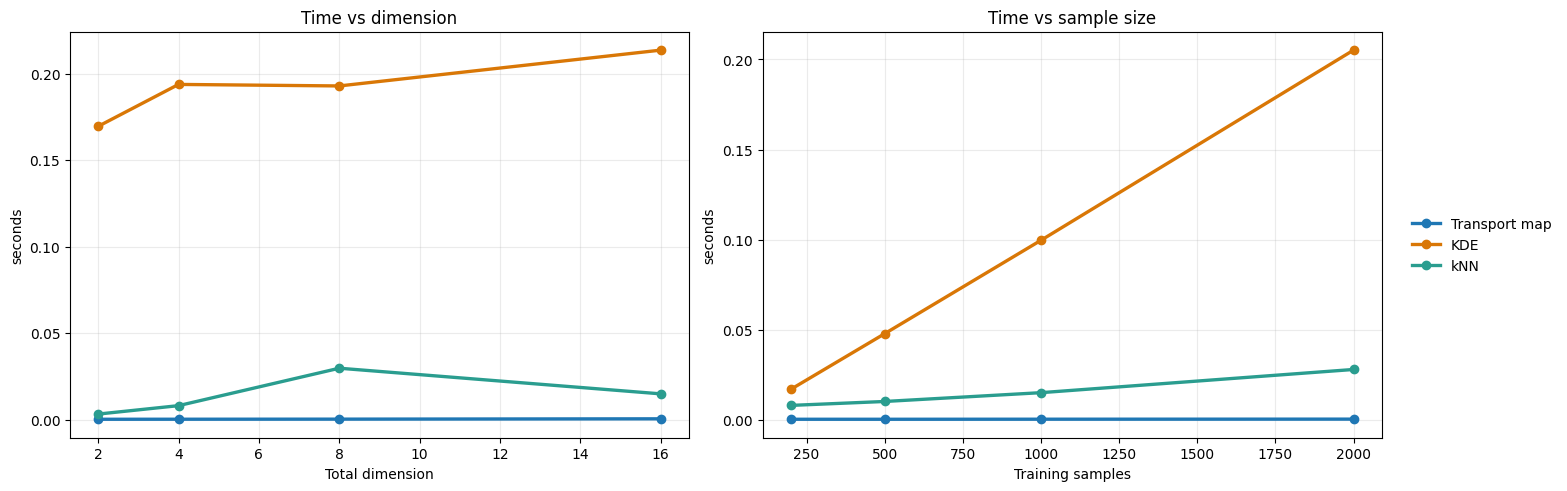

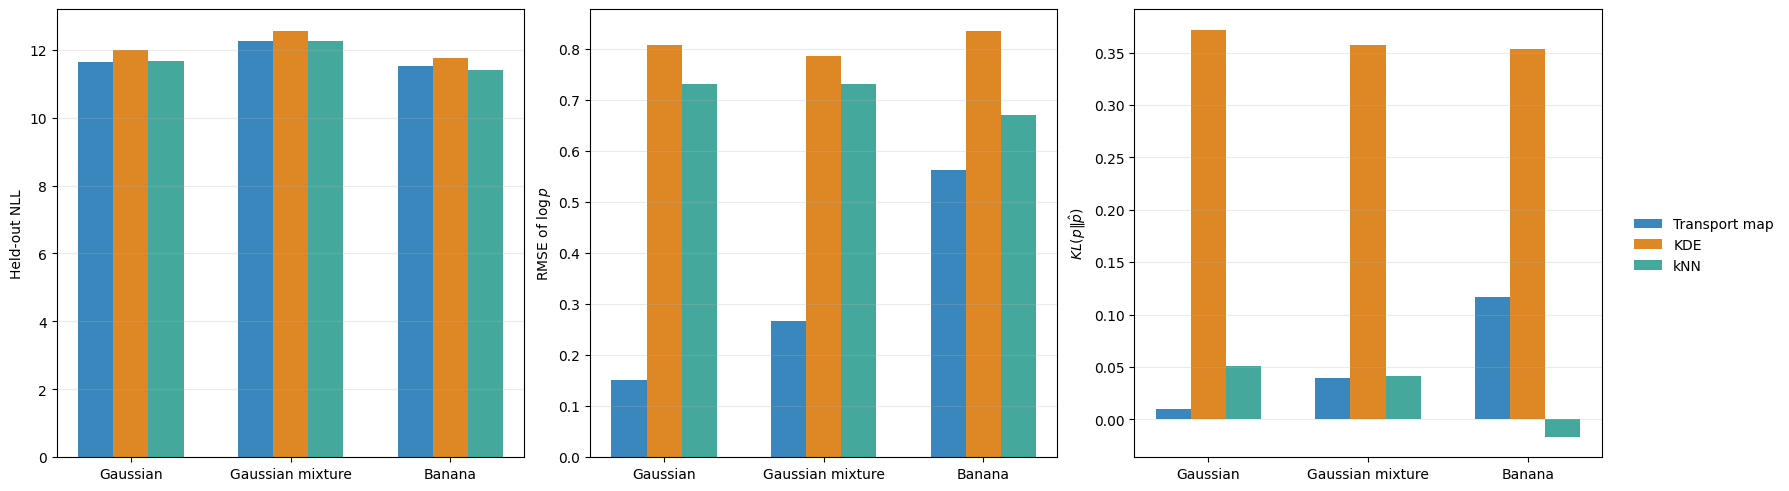

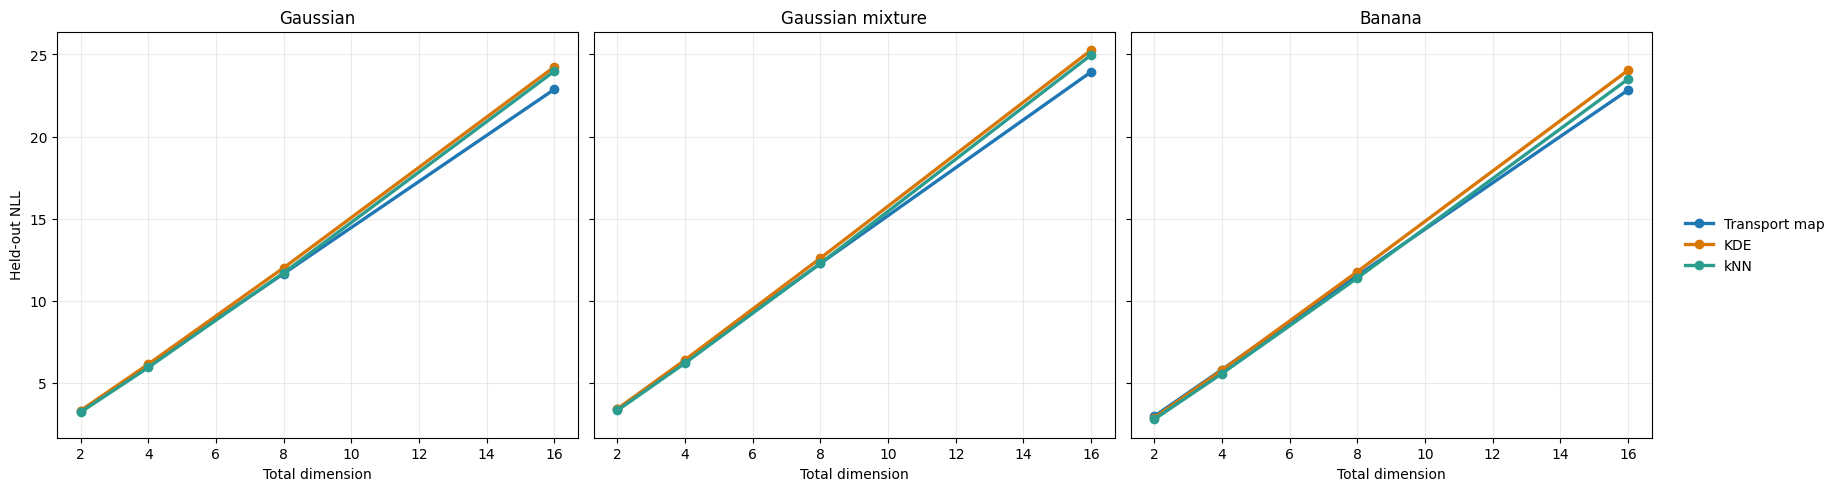

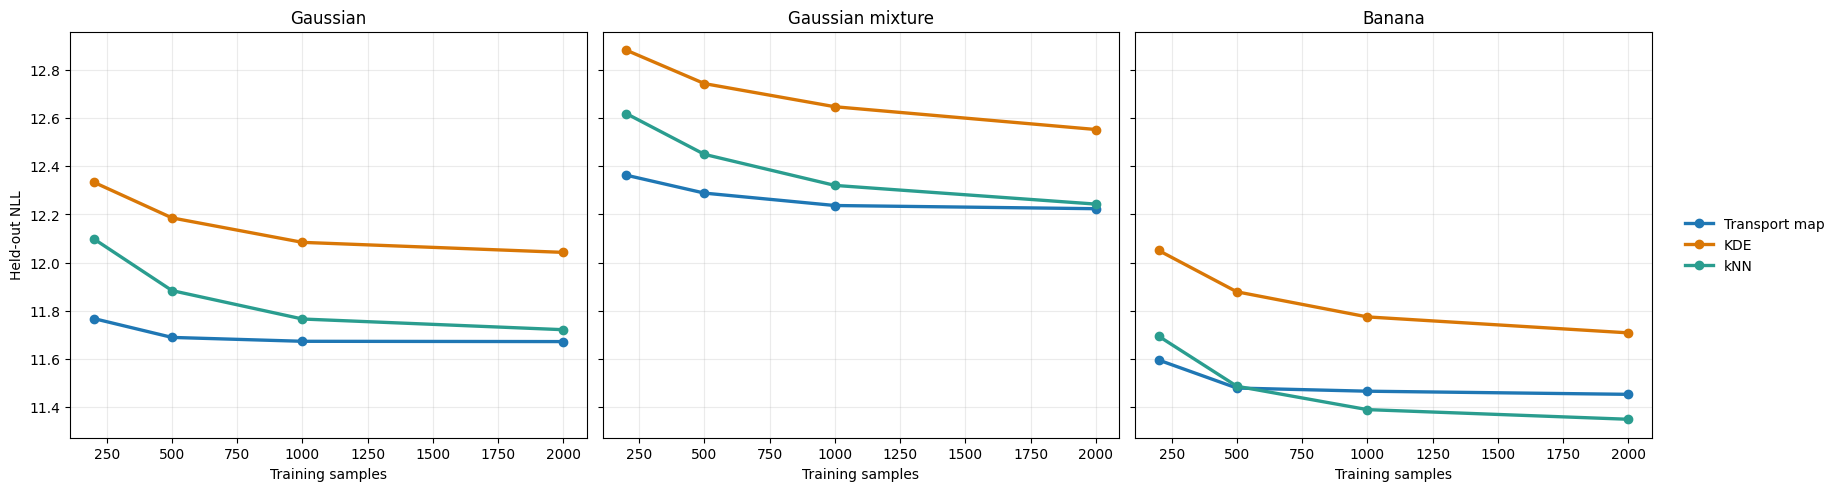

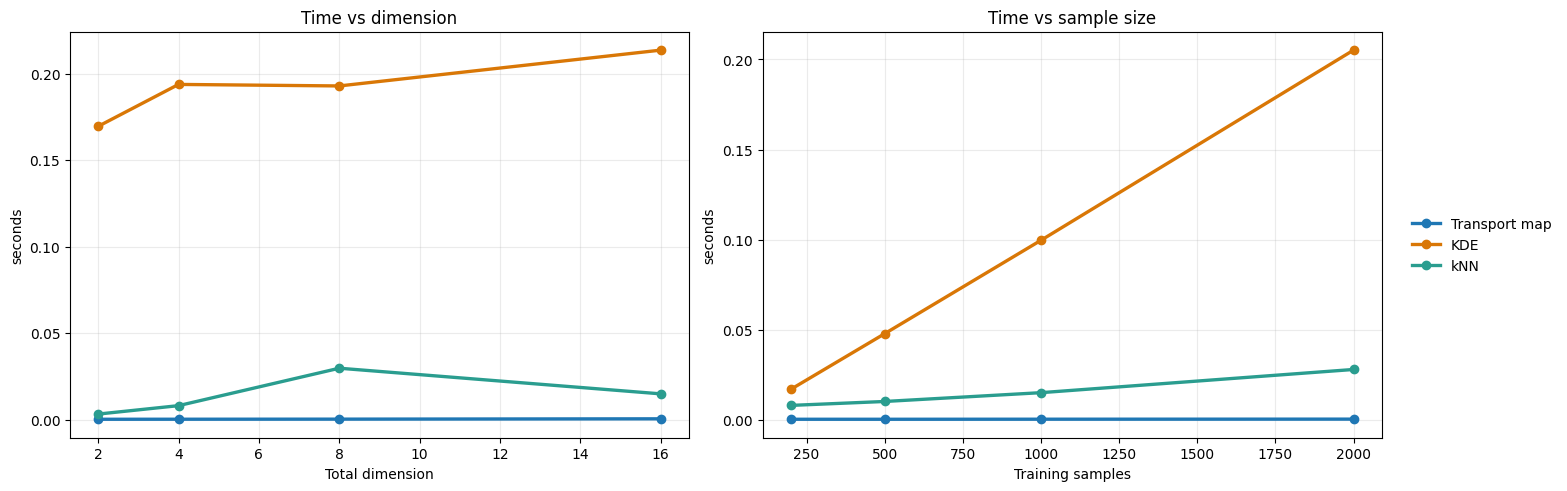

In [5]:
plot_density_accuracy_summary(density_accuracy_summary)
plot_density_robustness_scan(
    density_dimension_summary,
    x_key='total_dim',
    y_key='heldout_nll_mean',
    xlabel='Total dimension',
    output_name='density_dimension_robustness.png',
)
plot_density_robustness_scan(
    density_sample_size_summary,
    x_key='n_train',
    y_key='heldout_nll_mean',
    xlabel='Training samples',
    output_name='density_sample_size_robustness.png',
)
plot_density_timing_summary(density_timing_summary)



## 结果解读

如果 transport-map 风格估计器工作正常，默认应该看到下面几件事：
- 在样本量增加时，`transport_map` 的平均估计更接近解析真值，偏差下降；
- 在维度升高时，kNN 基线的误差和波动更容易变大；
- 仿射下三角 transport map 在这个高斯案例里通常更稳定，因为它直接利用了高维连续分布的几何结构。

这并不意味着所有连续分布都可以只用仿射 map 解决。更一般的非高斯情形仍然需要更灵活的非线性 map。
但作为第一步，这个 notebook 已经完整展示了 transport map 如何被用来估计连续变量之间的互信息。


## 局限与后续扩展

- 当前案例是高斯 benchmark，因此这里的 transport map 退化成了一个仿射下三角 map；
- 若要更贴近论文中的一般设置，可以把 `fit_density` 替换成更高阶的非线性 triangular map；
- 当前 notebook 的重点是验证高维连续分布下的偏差、稳定性和基线比较，而不是覆盖所有分布族。


## 输出约定

- 缓存文件写到 `exp/cache/density_benchmark/`；
- 图像与 manifest 写到 `fig/transport_map_mutual_information/`；
- 若环境没有 `pyarrow/fastparquet`，原始 DataFrame 缓存会自动回退到 `pickle`。
